# Python Controle Discret

In [2]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import StateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel

from Control.DiscretePID import DiscretePID

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridControlLoop
from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting

import numpy as np
import control as ct
import matplotlib.pyplot as plt



In [3]:
%matplotlib inline

## Mise en place

#### Système
Ici, on spécifie l'état initial, la méthode TransferFunctionModel() donne sa fonction de tranfert qu'on met ensuite dans le simualteur de fonctions de transfert

In [6]:
X_0 = np.array([[0], [0]])
model = TransferFunctionModel(ballbeam_config)
plant_sim = TFSimulator(model.Tf_dis, 0)

#### Réponse inditielle et impultionelle 
Le but est de comparer notre simualtion a celle de la librairie python

1) Réponse impulsionelle

In [9]:


## simulateur 
impulse_logger=SimLog()
impulse_logger=run_impulse_response_sim(plant_sim,ballbeam_config,0.0,impulse_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.impulse_response(model.Tf_dis, t)

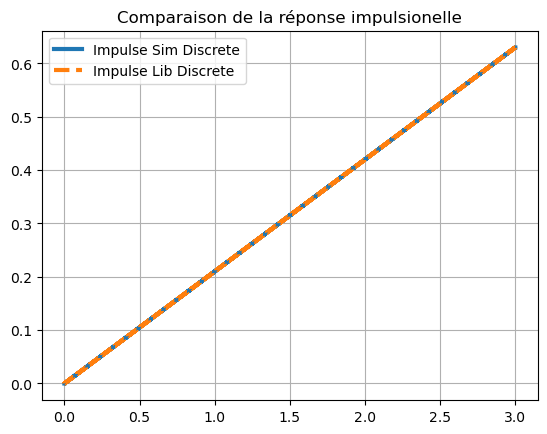

In [10]:
fig1=plt.figure()
plt.step(
    impulse_logger.t_hist,
    impulse_logger.y_hist,
    linestyle='-',
    label="Impulse Sim Discrete",
    linewidth=3,
)

plt.step(
    t,
    y_lib,
    linestyle='--',
    linewidth=3,
    label="Impulse Lib Discrete"
)
plt.grid()
plt.title('Comparaison de la réponse impulsionelle')
plt.legend()
plt.savefig('Réponse_Impulsionelle_Discrete.png')
plt.show()


##### Réponse inditielle

In [12]:
## simulateur 
step_logger=SimLog()
step_logger=run_step_response_sim(plant_sim,ballbeam_config,0.0,step_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.step_response(model.Tf_dis, t)

In [13]:
_, y_lib = ct.step_response(model.Tf_cont, t)

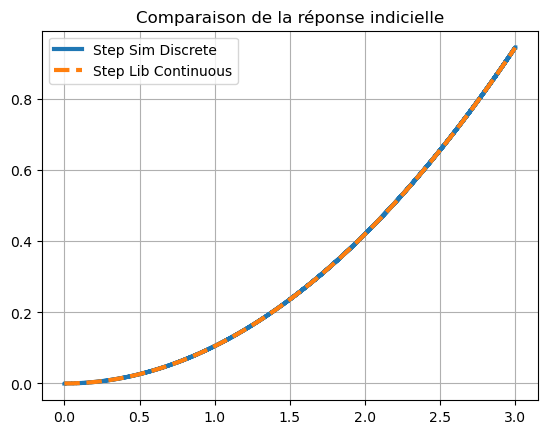

In [14]:
fig3=plt.figure()
plt.step(
    step_logger.t_hist,
    step_logger.y_hist,
    linestyle='-',
    label="Step Sim Discrete",
    linewidth=3,
)

plt.plot(
    t,
    y_lib,
    linestyle='--',
    linewidth=3,
    label="Step Lib Continuous"
)
plt.grid()
plt.title('Comparaison de la réponse indicielle')
plt.legend()
plt.savefig('Réponse_Indicielle_Continue.png')
plt.show()


## Controle PID et validation


#### Mise en place du PID

In [17]:

kp, ki, kd = 19, 0, 13
r = 1.0
PID = DiscretePID(kp,ki,kd,10,ballbeam_config.dt)
PID.setReference(r)
controller_sim = TFSimulator(PID.PID_TF, 0)
PID.reset()

#### Modele en espace d'états (utilisé pour la simulation hybride)

In [19]:
plant_model = StateSpaceModel(ballbeam_config)
hybrid_loop = HybridControlLoop(
    plant_model,
    PID,
    ballbeam_config
)

In [20]:
logger_hybrid_step = SimLog()

logger_hybrid_step = hybrid_loop.run_step_response( X_0,logger_hybrid_step)

_, y_lib1 = ct.step_response(model.Tf_cont, t)

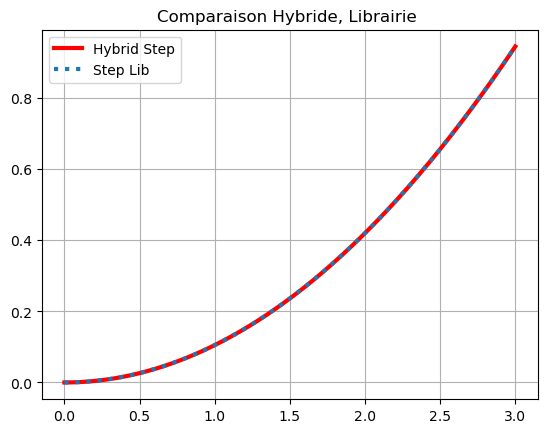

In [21]:
plt.figure()

plt.plot(
    logger_hybrid_step.t_hist,
    logger_hybrid_step.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Step"
)
plt.plot(
    t,
    y_lib1,
    linestyle=':',
    linewidth=3,
    label="Step Lib"
)
plt.title("Comparaison Hybride, Librairie ")
plt.grid()
plt.legend()
plt.savefig('Réponse_Indicielle_Hybride.png')
plt.show()

In [22]:
hybrid_loop = HybridControlLoop(plant_model,PID,ballbeam_config)
logger_hybrid = SimLog()

logger_hybrid = hybrid_loop.run_continuous_control_loop( X_0,logger_hybrid)


In [23]:
L = PID.PID_TF * model.Tf_dis
T = ct.feedback(L, 1)

t = np.arange(
    0,
    ballbeam_config.T,
    ballbeam_config.dt
)

_, y_lib = ct.step_response(T, t)

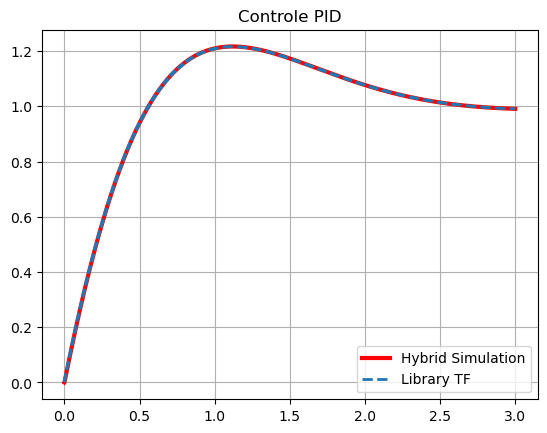

In [24]:
plt.figure()

plt.plot(
    logger_hybrid.t_hist,
    logger_hybrid.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)
plt.step(t, y_lib, label="Library TF",linewidth=2,
    linestyle='--',)
plt.title("Controle PID")
plt.grid()
plt.legend()
plt.savefig('Réponse_Indicielle_PID.png')
plt.show()

In [25]:
print(y_lib[:5])
print(logger_hybrid.y_hist[:5])
print(np.array(logger_hybrid.y_hist[:5]) / y_lib[:5])

[0.00136513 0.00409365 0.00681869 0.00954026 0.01225835]
[0.0, 2.7339900000000013e-07, 8.201970000000003e-07, 1.6403940000000007e-06, 2.7339900000000014e-06]
[0.00000000e+00 6.67861358e-05 1.20286536e-04 1.71944365e-04
 2.23030856e-04]
